In [82]:
# Core data manipulation
import pandas as pd
import numpy as np
from numpy import polyfit, poly1d

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tools
from scipy import stats

## About the Dataset

**Dataset:** OWID COVID-19 Dataset  
**Source:** https://github.com/owid  
**File:** `owid-covid-data.csv`   

In [16]:
owid = pd.read_csv('owid-covid-data.csv')
display(owid.head())

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [35]:
# shape
print(owid.shape)
print(f'\nThere are {owid.shape[0]} rows and {owid.shape[1]} columns\n')
print('- Each row is one case of COVID')

(429435, 67)

There are 429435 rows and 67 columns

- Each row is one case of COVID


In [45]:
# 2. & 3 Column Names & Data Types
print("\nColumn Names and Data Types:")
for col in owid.columns:
    print(f"  - {col}: {owid[col].dtype}")


Column Names and Data Types:
  - iso_code: object
  - continent: object
  - location: object
  - date: object
  - total_cases: float64
  - new_cases: float64
  - new_cases_smoothed: float64
  - total_deaths: float64
  - new_deaths: float64
  - new_deaths_smoothed: float64
  - total_cases_per_million: float64
  - new_cases_per_million: float64
  - new_cases_smoothed_per_million: float64
  - total_deaths_per_million: float64
  - new_deaths_per_million: float64
  - new_deaths_smoothed_per_million: float64
  - reproduction_rate: float64
  - icu_patients: float64
  - icu_patients_per_million: float64
  - hosp_patients: float64
  - hosp_patients_per_million: float64
  - weekly_icu_admissions: float64
  - weekly_icu_admissions_per_million: float64
  - weekly_hosp_admissions: float64
  - weekly_hosp_admissions_per_million: float64
  - total_tests: float64
  - new_tests: float64
  - total_tests_per_thousand: float64
  - new_tests_per_thousand: float64
  - new_tests_smoothed: float64
  - new_te

The dataset contains 67 variables including identifiers (e.g., country codes),
temporal variables (date), and epidemiological measures such as cases,
deaths, and vaccinations.

In [48]:
classification = []

for col in owid.columns:
    if col in {'date', 'iso_code'}:
        classification.append({
            'column': col,
            'data_type': 'identifier / temporal',
            'measurement_type': 'not applicable'
        })
    elif owid[col].dtype == 'object':
        classification.append({
            'column': col,
            'data_type': 'categorical',
            'measurement_type': 'categorical (nominal)'
        })
    else:
        values = owid[col].dropna()
        if len(values) > 0 and ((values % 1) == 0).all():
            measurement = 'discrete'
        else:
            measurement = 'continuous'

        classification.append({
            'column': col,
            'data_type': 'quantitative',
            'measurement_type': measurement
        })

classification_df = pd.DataFrame(classification)
classification_df

,column,data_type,measurement_type
0,iso_code,identifier / temporal,not applicable
1,continent,categorical,categorical (nominal)
2,location,categorical,categorical (nominal)
3,date,identifier / temporal,not applicable
4,total_cases,quantitative,discrete
...,...,...,...
62,population,quantitative,discrete
63,excess_mortality_cumulative_absolute,quantitative,continuous
64,excess_mortality_cumulative,quantitative,continuous
65,excess_mortality,quantitative,continuous


Numeric variables representing counts (e.g., cases, deaths) are treated as
**discrete**, while rates and averages are treated as **continuous**.
Identifier and date columns are excluded from quantitative analysis.

In [50]:
# categorical columns
categorical_cols = owid.select_dtypes(include='object').columns

categorical_values = {
    col: owid[col].dropna().unique()
    for col in categorical_cols
}

categorical_values

{'iso_code': array(['AFG', 'OWID_AFR', 'ALB', 'DZA', 'ASM', 'AND', 'AGO', 'AIA', 'ATG',
        'ARG', 'ARM', 'ABW', 'OWID_ASI', 'AUS', 'AUT', 'AZE', 'BHS', 'BHR',
        'BGD', 'BRB', 'BLR', 'BEL', 'BLZ', 'BEN', 'BMU', 'BTN', 'BOL',
        'BES', 'BIH', 'BWA', 'BRA', 'VGB', 'BRN', 'BGR', 'BFA', 'BDI',
        'KHM', 'CMR', 'CAN', 'CPV', 'CYM', 'CAF', 'TCD', 'CHL', 'CHN',
        'COL', 'COM', 'COG', 'COK', 'CRI', 'CIV', 'HRV', 'CUB', 'CUW',
        'CYP', 'CZE', 'COD', 'DNK', 'DJI', 'DMA', 'DOM', 'TLS', 'ECU',
        'EGY', 'SLV', 'OWID_ENG', 'GNQ', 'ERI', 'EST', 'SWZ', 'ETH',
        'OWID_EUR', 'OWID_EUN', 'FRO', 'FLK', 'FJI', 'FIN', 'FRA', 'GUF',
        'PYF', 'GAB', 'GMB', 'GEO', 'DEU', 'GHA', 'GIB', 'GRC', 'GRL',
        'GRD', 'GLP', 'GUM', 'GTM', 'GGY', 'GIN', 'GNB', 'GUY', 'HTI',
        'OWID_HIC', 'HND', 'HKG', 'HUN', 'ISL', 'IND', 'IDN', 'IRN', 'IRQ',
        'IRL', 'IMN', 'ISR', 'ITA', 'JAM', 'JPN', 'JEY', 'JOR', 'KAZ',
        'KEN', 'KIR', 'OWID_KOS', 'KWT', 'KGZ', '

In [51]:
categorical_summary = []

for col in categorical_cols:
    counts = owid[col].value_counts()
    categorical_summary.append({
        'column': col,
        'unique_values': owid[col].nunique(),
        'mode': counts.idxmax(),
        'mode_count': counts.max()
    })

pd.DataFrame(categorical_summary)

,column,unique_values,mode,mode_count
0,iso_code,255,OWID_HIC,3026
1,continent,6,Africa,95419
2,location,255,High-income countries,3026
3,date,1688,2022-01-10,261
4,tests_units,4,tests performed,80099


For categorical variables, the mode was identified as the most frequently
occurring category based on value counts.

In [49]:
# numeric columns
numeric_cols = owid.select_dtypes(include='number').columns

quant_summary = []

for col in numeric_cols:
    quant_summary.append({
        'column': col,
        'min': owid[col].min(),
        'max': owid[col].max(),
        'mean': owid[col].mean(),
        'median': owid[col].median(),
        'std': owid[col].std()
    })

quant_df = pd.DataFrame(quant_summary)
quant_df

,column,min,max,mean,median,std
0,total_cases,0.00,7.758668e+08,7.365292e+06,63653.00,4.477582e+07
1,new_cases,0.00,4.423623e+07,8.017360e+03,0.00,2.296649e+05
2,new_cases_smoothed,0.00,6.319461e+06,8.041026e+03,12.00,8.661611e+04
3,total_deaths,0.00,7.057132e+06,8.125957e+04,799.00,4.411901e+05
4,new_deaths,0.00,1.037190e+05,7.185214e+01,0.00,1.368323e+03
...,...,...,...,...,...,...
57,population,47.00,7.975105e+09,1.520336e+08,6336393.00,6.975408e+08
58,excess_mortality_cumulative_absolute,-37726.10,1.349776e+06,5.604765e+04,6815.20,1.568691e+05
59,excess_mortality_cumulative,-44.23,7.808000e+01,9.766431e+00,8.13,1.204066e+01
60,excess_mortality,-95.92,3.782200e+02,1.092535e+01,5.66,2.456071e+01


Statistics are reported only for variables where they are meaningful.
Count-based variables (e.g., cases, deaths, vaccinations) are measured in
**number of people**, while rate-based variables are measured in **percentages
or per-capita units**.

Identifier variables (e.g., codes or IDs) are excluded, as summary statistics
would be misleading.

In [54]:
skip_cols = {'iso_code', 'date'}

summary = []

for col in owid.columns:
    missing_pct = owid[col].isna().mean() * 100

    # Categorical
    if owid[col].dtype == 'object':
        summary.append({
            'Column': col,
            'Type': 'Categorical',
            'Measurement': 'Nominal',
            'Missing %': round(missing_pct, 2),
            'Details': f"Unique values: {owid[col].nunique()}, "
                       f"Mode: {owid[col].mode().iloc[0]}"
        })

    # Numeric
    else:
        values = owid[col].dropna()
        measurement = (
            'Discrete'
            if len(values) > 0 and ((values % 1) == 0).all()
            else 'Continuous'
        )

        summary.append({
            'Column': col,
            'Type': 'Quantitative',
            'Measurement': measurement,
            'Missing %': round(missing_pct, 2),
            'Details': (
                f"Range: {values.min():.2f}–{values.max():.2f}, "
                f"Mean: {values.mean():.2f}, "
                f"Median: {values.median():.2f}, "
                f"Std: {values.std():.2f}"
            )
        })

summary_df = pd.DataFrame(summary)

summary_df = summary_df.sort_values(by=['Type', 'Measurement', 'Missing %'], ascending=[True, True, False])

summary_df

,Column,Type,Measurement,Missing %,Details
33,tests_units,Categorical,Nominal,75.13,"Unique values: 4, Mode: tests performed"
1,continent,Categorical,Nominal,6.18,"Unique values: 6, Mode: Africa"
0,iso_code,Categorical,Nominal,0.00,"Unique values: 255, Mode: OWID_HIC"
2,location,Categorical,Nominal,0.00,"Unique values: 255, Mode: High-income countries"
3,date,Categorical,Nominal,0.00,"Unique values: 1688, Mode: 2021-02-15"
...,...,...,...,...,...
5,new_cases,Quantitative,Discrete,4.49,"Range: 0.00–44236227.00, Mean: 8017.36, Median..."
8,new_deaths,Quantitative,Discrete,4.38,"Range: 0.00–103719.00, Mean: 71.85, Median: 0...."
4,total_cases,Quantitative,Discrete,4.11,"Range: 0.00–775866783.00, Mean: 7365292.35, Me..."
7,total_deaths,Quantitative,Discrete,4.11,"Range: 0.00–7057132.00, Mean: 81259.57, Median..."


The table above summarizes all variables in the dataset, including data type,
measurement scale, missingness, and relevant descriptive statistics.
Statistics are reported only where meaningful.

## Missing Value Check

In [56]:
# Check missing values
missing_summary = owid.isna().sum().to_frame('missing_count')
missing_summary['missing_pct'] = (missing_summary['missing_count'] / len(owid) * 100).round(2)
missing_summary.sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
weekly_icu_admissions_per_million,418442,97.44
weekly_icu_admissions,418442,97.44
excess_mortality_cumulative_per_million,416024,96.88
excess_mortality,416024,96.88
excess_mortality_cumulative,416024,96.88
...,...,...
total_deaths,17631,4.11
population,0,0.00
date,0,0.00
location,0,0.00


In [57]:
# fill categorical data with mode
categorical_cols = owid.select_dtypes(include='object').columns

for col in categorical_cols:
    mode_val = owid[col].mode()[0]
    owid[col].fillna(mode_val, inplace=True)

In [58]:
# fill numerical data with mean (if makes sense)
numeric_cols = owid.select_dtypes(include='number').columns

for col in numeric_cols:
    mean_val = owid[col].mean()
    owid[col].fillna(mean_val, inplace=True)

In [59]:
# if a row is missing an identifier or date, drop it
owid.dropna(subset=['iso_code', 'date'], inplace=True)

In [60]:
# Missing values per column after filling
owid.isna().sum()

iso_code                                   0
continent                                  0
location                                   0
date                                       0
total_cases                                0
                                          ..
population                                 0
excess_mortality_cumulative_absolute       0
excess_mortality_cumulative                0
excess_mortality                           0
excess_mortality_cumulative_per_million    0
Length: 67, dtype: int64

## Sanity Check

In [62]:
# Ensure all counts/ratios are non-negative
numeric_checks = numeric_cols[numeric_cols.str.contains('cases|deaths|tests|vaccinations|population', case=False)]
for col in numeric_checks:
    if (owid[col] < 0).any():
        print(f"Warning: negative values in {col}")

In [63]:
# Ensure date is datetime type
owid['date'] = pd.to_datetime(owid['date'])

## Duplicate Check

In [64]:
duplicates = owid.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")

Number of duplicate rows: 0


## Stats

In [65]:
owid.describe().T

,count,mean,min,25%,50%,75%,max,std
date,429435,2022-04-21 01:06:25.463691008,2020-01-01 00:00:00,2021-03-05 00:00:00,2022-04-20 00:00:00,2023-06-08 00:00:00,2024-08-14 00:00:00,NaN
total_cases,429435.0,7365292.354484,0.0,7034.0,75015.0,1064237.0,775866783.0,43847017.384509
new_cases,429435.0,8017.359934,0.0,0.0,0.0,0.0,44236227.0,224451.206264
new_cases_smoothed,429435.0,8041.025764,0.0,0.0,16.57,529.14,6319461.0,84522.803377
total_deaths,429435.0,81259.574278,0.0,53.0,940.0,13719.0,7057132.0,432038.387193
...,...,...,...,...,...,...,...,...
population,429435.0,152033640.396274,47.0,523798.0,6336393.0,32969520.0,7975105024.0,697540771.6681
excess_mortality_cumulative_absolute,429435.0,56047.653551,-37726.1,56047.653551,56047.653551,56047.653551,1349776.4,27720.65662
excess_mortality_cumulative,429435.0,9.766431,-44.23,9.766431,9.766431,9.766431,78.08,2.127729
excess_mortality,429435.0,10.925353,-95.92,10.925353,10.925353,10.925353,378.22,4.340173


In [79]:
correlation_matrix = owid[numeric_cols].corr(method='pearson')
print(correlation_matrix)

                                         total_cases  new_cases  \
total_cases                                 1.000000   0.127225   
new_cases                                   0.127225   1.000000   
new_cases_smoothed                          0.337766   0.376575   
total_deaths                                0.945601   0.155688   
new_deaths                                  0.099157   0.505690   
...                                              ...        ...   
population                                  0.647646   0.139007   
excess_mortality_cumulative_absolute        0.031871   0.034182   
excess_mortality_cumulative                 0.002534   0.004229   
excess_mortality                           -0.001373   0.008645   
excess_mortality_cumulative_per_million     0.007226   0.001893   

                                         new_cases_smoothed  total_deaths  \
total_cases                                        0.337766      0.945601   
new_cases                                

In [80]:
corr = owid[key_cols].corr().abs()
high_corr_pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
                       .stack()
                       .sort_values(ascending=False))
high_corr_pairs = high_corr_pairs[high_corr_pairs > 0.5]
print(high_corr_pairs)

total_vaccinations  people_vaccinated     0.987312
total_cases         total_deaths          0.945601
people_vaccinated   population            0.722586
total_vaccinations  population            0.710884
total_deaths        population            0.709433
total_cases         total_vaccinations    0.682470
                    people_vaccinated     0.677026
total_deaths        people_vaccinated     0.661054
                    total_vaccinations    0.653898
total_cases         population            0.647646
new_cases           new_deaths            0.505690
dtype: float64


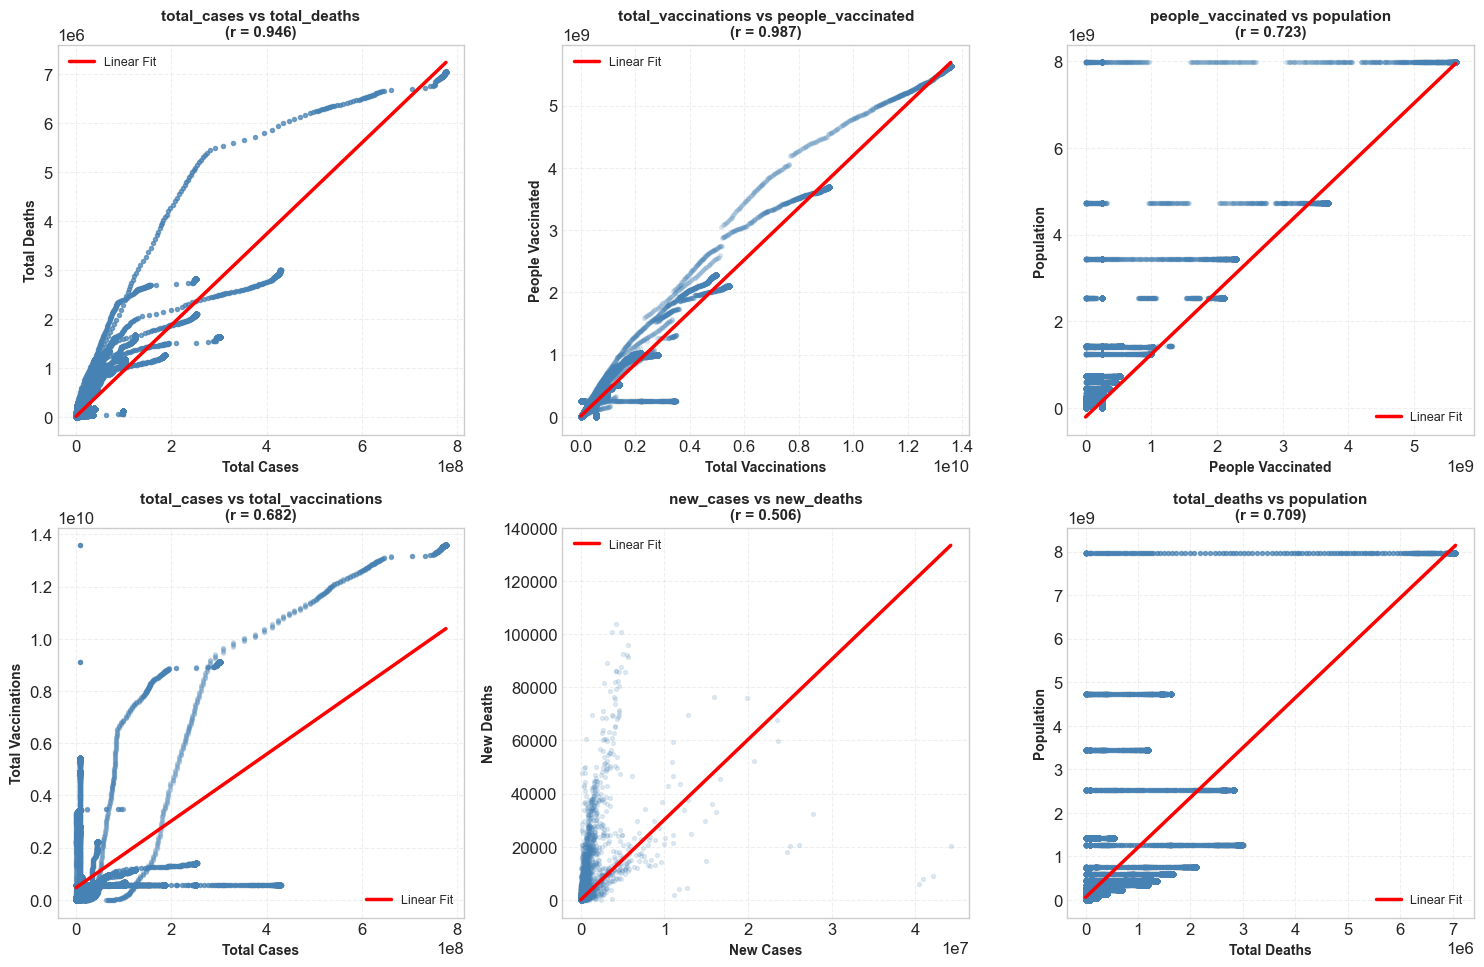

✓ Correlation visualizations created and saved as 'top_correlations.png'


In [89]:
## Visualization of Top Correlations

# Define top correlation pairs from our analysis
top_pairs = [
    ('total_cases', 'total_deaths', 0.946),
    ('total_vaccinations', 'people_vaccinated', 0.987),
    ('people_vaccinated', 'population', 0.723),
    ('total_cases', 'total_vaccinations', 0.682),
    ('new_cases', 'new_deaths', 0.506),
    ('total_deaths', 'population', 0.709),
]

# Create subplots grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (var_x, var_y, corr_value) in enumerate(top_pairs):
    ax = axes[idx]
    
    # Create scatter plot with transparency to handle overlapping points
    ax.scatter(owid[var_x], owid[var_y], alpha=0.15, s=8, color='steelblue')
    
    # Add regression line
    z = np.polyfit(owid[var_x], owid[var_y], 1)
    p = np.poly1d(z)
    x_line = np.linspace(owid[var_x].min(), owid[var_x].max(), 100)
    ax.plot(x_line, p(x_line), "r-", linewidth=2.5, label=f'Linear Fit')
    
    # Formatting
    ax.set_xlabel(var_x.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_ylabel(var_y.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_title(f'{var_x} vs {var_y}\n(r = {corr_value:.3f})', fontsize=11, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('top_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Correlation visualizations created and saved as 'top_correlations.png'")

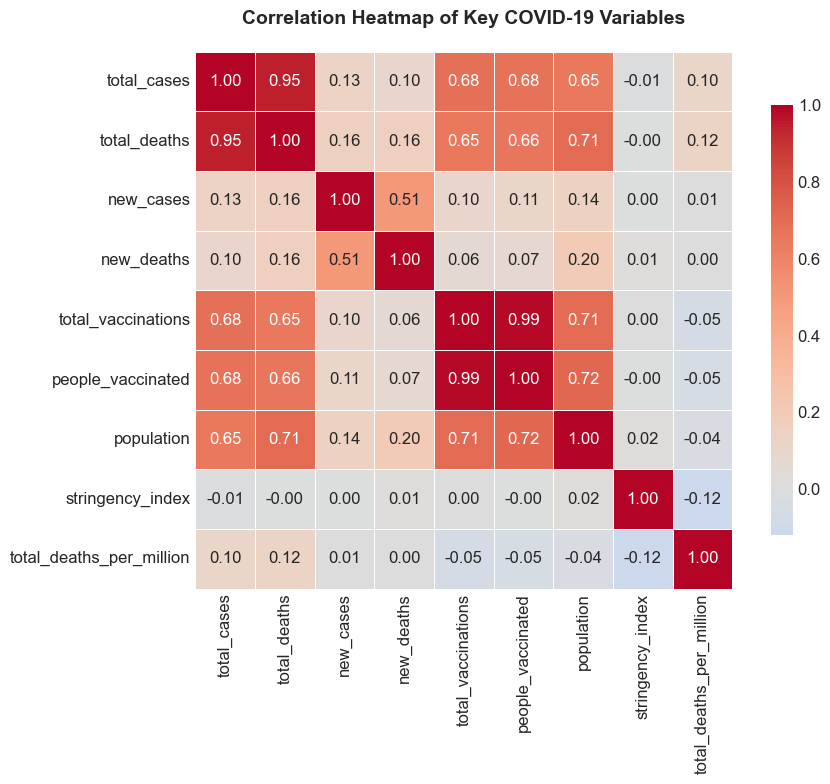

✓ Correlation heatmap created and saved as 'correlation_heatmap.png'


In [90]:
## Correlation Heatmap

# Select key variables related to your research
key_vars = [
    'total_cases', 'total_deaths', 'new_cases', 'new_deaths',
    'total_vaccinations', 'people_vaccinated', 'population',
    'stringency_index', 'total_deaths_per_million'
]

# Create correlation matrix for key variables
corr_matrix = owid[key_vars].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Key COVID-19 Variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Correlation heatmap created and saved as 'correlation_heatmap.png'")

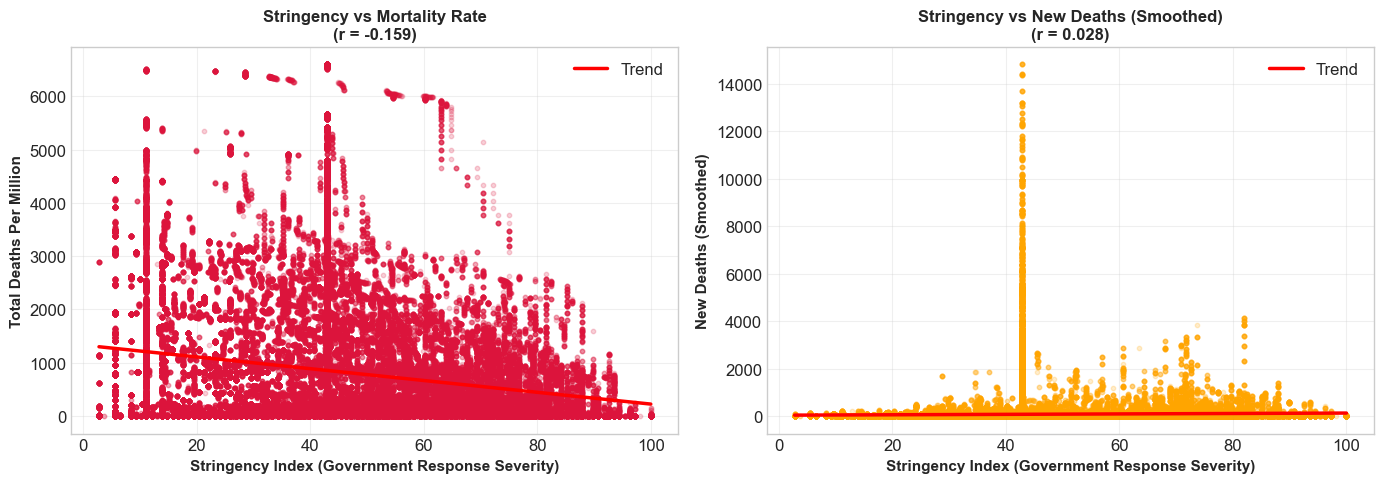

✓ Stringency analysis complete
  - Correlation (Stringency vs Deaths/Million): -0.1588
  - Correlation (Stringency vs New Deaths): 0.0284


In [91]:
## Analysis: Stringency Index vs Mortality 

# Remove rows with missing stringency_index
data_with_stringency = owid[owid['stringency_index'] > 0].copy()

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Stringency vs Total Deaths Per Million
ax1 = axes[0]
ax1.scatter(data_with_stringency['stringency_index'], 
            data_with_stringency['total_deaths_per_million'],
            alpha=0.2, s=10, color='crimson')
# Add trend line
z1 = np.polyfit(data_with_stringency['stringency_index'], 
                data_with_stringency['total_deaths_per_million'], 1)
p1 = np.poly1d(z1)
x_range = np.linspace(data_with_stringency['stringency_index'].min(), 
                      data_with_stringency['stringency_index'].max(), 100)
ax1.plot(x_range, p1(x_range), 'r-', linewidth=2.5, label='Trend')
corr1 = data_with_stringency['stringency_index'].corr(data_with_stringency['total_deaths_per_million'])
ax1.set_xlabel('Stringency Index (Government Response Severity)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Total Deaths Per Million', fontsize=11, fontweight='bold')
ax1.set_title(f'Stringency vs Mortality Rate\n(r = {corr1:.3f})', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Stringency vs New Deaths Smoothed
ax2 = axes[1]
ax2.scatter(data_with_stringency['stringency_index'], 
            data_with_stringency['new_deaths_smoothed'],
            alpha=0.2, s=10, color='orange')
# Add trend line
z2 = np.polyfit(data_with_stringency['stringency_index'], 
                data_with_stringency['new_deaths_smoothed'], 1)
p2 = np.poly1d(z2)
ax2.plot(x_range, p2(x_range), 'r-', linewidth=2.5, label='Trend')
corr2 = data_with_stringency['stringency_index'].corr(data_with_stringency['new_deaths_smoothed'])
ax2.set_xlabel('Stringency Index (Government Response Severity)', fontsize=11, fontweight='bold')
ax2.set_ylabel('New Deaths (Smoothed)', fontsize=11, fontweight='bold')
ax2.set_title(f'Stringency vs New Deaths (Smoothed)\n(r = {corr2:.3f})', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stringency_vs_mortality.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Stringency analysis complete")
print(f"  - Correlation (Stringency vs Deaths/Million): {corr1:.4f}")
print(f"  - Correlation (Stringency vs New Deaths): {corr2:.4f}")

## About the Dataset

**Dataset:** Oxford COVID-19 Governmetn Tracker  
**Source:** https://github.com/OxCGRT/covid-policy-dataset/tree/main  
**File:** `OxCGRT_compact_national_v1.csv`   

In [ ]:
OxCGRT = pd.read_csv